1. Wczytywanie danych i podział (TARGET_PET)...
2. Uczenie WERSJI 2.0 dla ZWIERZĄT (Lasso L1 i Płytsze Drzewa)...
(Info: Waga klasy pozytywnej wynosi: 120.3)
3. Analiza Progu (Cel biznesowy: Precyzja ~8%)...

--- RAPORT MODELU ZWIERZĘTA v2 (Próg: 73.9%) ---
                         precision    recall  f1-score   support

     Brak Zwierzaka (0)       0.99      0.99      0.99    104720
Leci ze Zwierzakiem (1)       0.08      0.14      0.10       870

               accuracy                           0.98    105590
              macro avg       0.54      0.56      0.55    105590
           weighted avg       0.99      0.98      0.98    105590


--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA ZWIERZĄT ---
Liczba kolumn na wejściu: 468
Kolumny użyte (przetrwały): 167
Kolumny wyzerowane (usunięte): 301

--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---


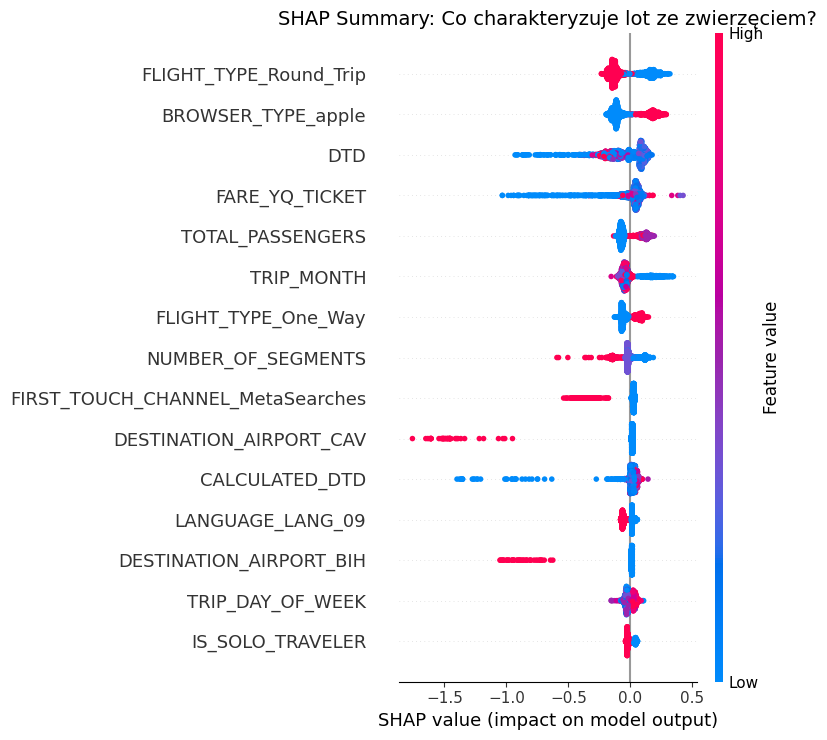

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import shap

warnings.filterwarnings('ignore')

print("1. Wczytywanie danych i podział (TARGET_PET)...")
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# Zmieniamy cel na PET (Zwierzak)
y = df_final['TARGET_PET'] 
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

# Oczyszczanie nazw kolumn
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("2. Uczenie WERSJI 2.0 dla ZWIERZĄT (Lasso L1 i Płytsze Drzewa)...")
# Wyrównanie klas - przy zwierzakach waga dla klasy '1' będzie potężna!
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"(Info: Waga klasy pozytywnej wynosi: {pos_weight:.1f})")

xgb_model_pet_v2 = xgb.XGBClassifier(
    n_estimators=300,          
    learning_rate=0.03,        
    max_depth=4,               
    colsample_bytree=0.8,      
    scale_pos_weight=pos_weight, 
    reg_alpha=50,              # POTĘŻNE LASSO (L1)
    reg_lambda=10,             # Ridge (L2)
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model_pet_v2.fit(X_train, y_train)

print("3. Analiza Progu (Cel biznesowy: Precyzja ~8%)...")
y_probs_pet_v2 = xgb_model_pet_v2.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_pet_v2)

# Celujemy w 8% precyzji, bo usługa jest ekstremalnie rzadka
target_precision = 0.08
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    # Jeśli 8% to za dużo dla modelu, bierzemy to, co dał radę wyciągnąć najwyżej
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

y_pred_pet_v2 = (y_probs_pet_v2 >= optimal_threshold).astype(int)

print(f"\n--- RAPORT MODELU ZWIERZĘTA v2 (Próg: {optimal_threshold*100:.1f}%) ---")
print(classification_report(y_test, y_pred_pet_v2, target_names=['Brak Zwierzaka (0)', 'Leci ze Zwierzakiem (1)']))

# --- EFEKT EKSTREMALNEJ REGULARYZACJI ---
print("\n--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA ZWIERZĄT ---")
used_features = xgb_model_pet_v2.get_booster().get_fscore()
num_used = len(used_features)
num_total = X.shape[1]
print(f"Liczba kolumn na wejściu: {num_total}")
print(f"Kolumny użyte (przetrwały): {num_used}")
print(f"Kolumny wyzerowane (usunięte): {num_total - num_used}")

# --- MAGIA SHAP: Kto lata ze zwierzętami? ---
print("\n--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---")
X_sample = X_test.head(2000)

explainer = shap.TreeExplainer(xgb_model_pet_v2)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 8))
plt.title('SHAP Summary: Co charakteryzuje lot ze zwierzęciem?', fontsize=14)
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()

xxx


1. Wczytywanie danych (TARGET_PET)...
2. Uczenie Modelu (Z wagą klas i Lasso L1)...
3. Ewaluacja (Domyślny, fabryczny próg = 50%)...

--- RAPORT MODELU (Domyślny Próg 50%) ---
                         precision    recall  f1-score   support

     Brak Zwierzaka (0)       1.00      0.75      0.85    104720
Leci ze Zwierzakiem (1)       0.02      0.61      0.04       870

               accuracy                           0.74    105590
              macro avg       0.51      0.68      0.45    105590
           weighted avg       0.99      0.74      0.85    105590



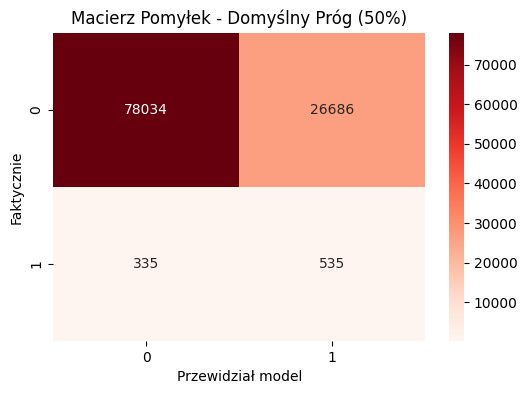

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

warnings.filterwarnings('ignore')

print("1. Wczytywanie danych (TARGET_PET)...")
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

y = df_final['TARGET_PET'] 
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("2. Uczenie Modelu (Z wagą klas i Lasso L1)...")
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model_default = xgb.XGBClassifier(
    n_estimators=300,          
    learning_rate=0.03,        
    max_depth=4,               
    colsample_bytree=0.8,      
    scale_pos_weight=pos_weight, # Sztuczne podbijanie wagi!
    reg_alpha=50,              
    reg_lambda=10,             
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model_default.fit(X_train, y_train)

print("3. Ewaluacja (Domyślny, fabryczny próg = 50%)...")
# --- ZERO KOMBINOWANIA, MODEL DECYDUJE SAM ---
y_pred_default = xgb_model_default.predict(X_test)

print("\n--- RAPORT MODELU (Domyślny Próg 50%) ---")
print(classification_report(y_test, y_pred_default, target_names=['Brak Zwierzaka (0)', 'Leci ze Zwierzakiem (1)']))

# Macierz pomyłek obnaży prawdę
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_default), annot=True, fmt='d', cmap='Reds')
plt.title('Macierz Pomyłek - Domyślny Próg (50%)')
plt.ylabel('Faktycznie')
plt.xlabel('Przewidział model')
plt.show()